In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [12]:
df = pd.read_csv("../Data/credit_risk.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [13]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicates ===")
print(df.duplicated().sum())
print("\n=== Target Distribution ===")
print(df["loan_status"].value_counts())

=== Data Types ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

=== Missing Values ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

=== Duplicates ===
165

=== Target Distribution ===
l

In [14]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill numeric missing values with median
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(f"Clean dataset shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Clean dataset shape: (32416, 12)
Remaining missing values: 0


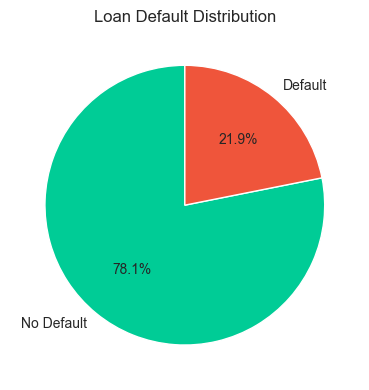

Default Rate: 21.87%


In [15]:
target_counts = df["loan_status"].value_counts()
labels = ["No Default", "Default"]

plt.figure(figsize=(6, 4))
plt.pie(target_counts, labels=labels, autopct="%1.1f%%",
        colors=["#00CC96", "#EF553B"], startangle=90)
plt.title("Loan Default Distribution")
plt.tight_layout()
plt.savefig("../default_distribution.png", dpi=150)
plt.show()

print(f"Default Rate: {df['loan_status'].mean()*100:.2f}%")

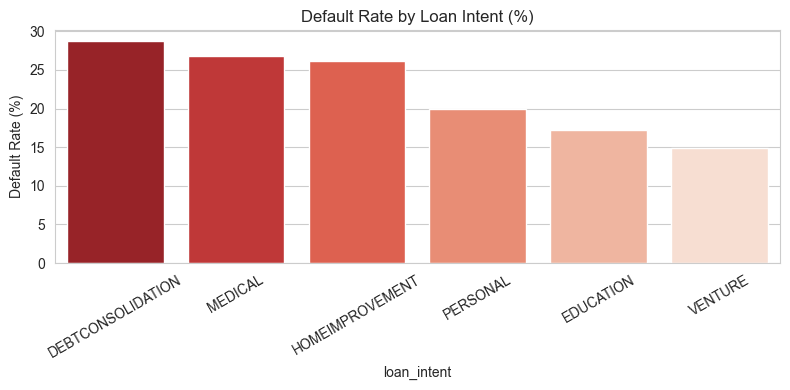

In [16]:
intent_default = df.groupby("loan_intent")["loan_status"].mean().reset_index()
intent_default["loan_status"] = (intent_default["loan_status"] * 100).round(2)
intent_default = intent_default.sort_values("loan_status", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=intent_default, x="loan_intent", y="loan_status",
            palette="Reds_r")
plt.title("Default Rate by Loan Intent (%)")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../default_by_intent.png", dpi=150)
plt.show()

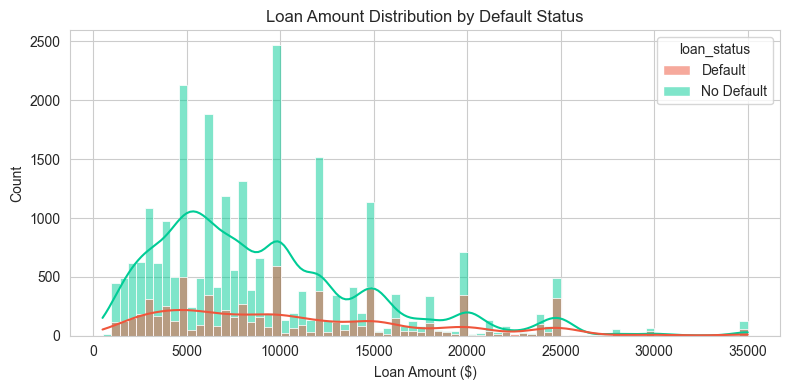

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="loan_amnt",
             hue=df["loan_status"].map({1: "Default", 0: "No Default"}),
             kde=True, palette=["#EF553B", "#00CC96"])
plt.title("Loan Amount Distribution by Default Status")
plt.xlabel("Loan Amount ($)")
plt.tight_layout()
plt.savefig("../loan_amount_distribution.png", dpi=150)
plt.show()

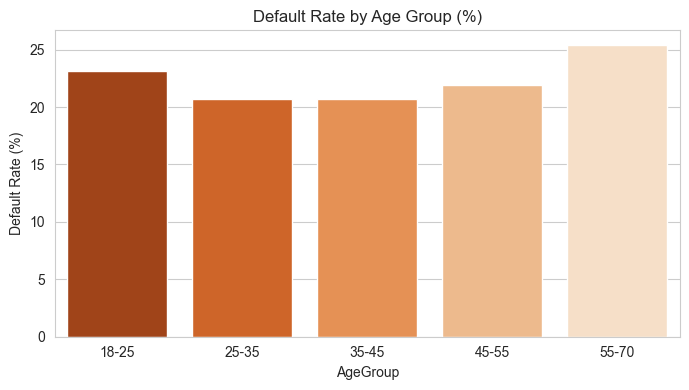

In [18]:
df["AgeGroup"] = pd.cut(df["person_age"],
                         bins=[18, 25, 35, 45, 55, 70],
                         labels=["18-25", "25-35", "35-45",
                                 "45-55", "55-70"])

age_default = df.groupby("AgeGroup")["loan_status"].mean().reset_index()
age_default["loan_status"] = (age_default["loan_status"] * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(data=age_default, x="AgeGroup", y="loan_status",
            palette="Oranges_r")
plt.title("Default Rate by Age Group (%)")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("../default_by_age.png", dpi=150)
plt.show()

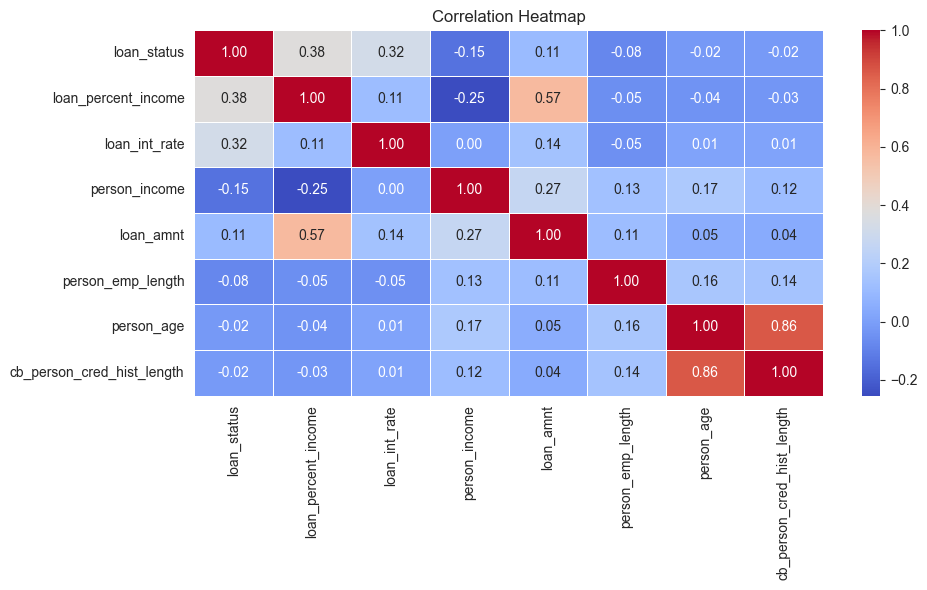

In [19]:
numeric_df = df.select_dtypes(include="number")

top_corr = numeric_df.corr()["loan_status"].abs().sort_values(
    ascending=False).head(10).index
top_df = numeric_df[top_corr]

plt.figure(figsize=(10, 6))
sns.heatmap(top_df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../correlation_heatmap.png", dpi=150)
plt.show()

## 📋 Key EDA Findings

1. **Default rate is ~22%** — about 1 in 5 loans ends in default
2. **Younger applicants (18–25)** have the highest default rate
3. **Medical and venture loan intents** show the highest default rates
4. **Higher loan amounts** are strongly linked to defaults
5. **Loan percent income** is the strongest predictor — the more of
   your income a loan takes up, the more likely you are to default